In [2]:
!pip install triton

In [3]:
import torch

import triton
import triton.language as tl

In [4]:
# this line asks Triton's active GPU driver version for the corresponding PyTorch device
DEVICE = triton.runtime.driver.active.get_active_torch_device()

Compute Kernel

In [5]:
@triton.jit
def add_k(x_ptr, y_ptr, out_ptr, num_el, BLOCK_SIZE: tl.constexpr):
  # 1st input vec, 2nd input vec, output vec, size of the vec, #of elements each program should process

  pid = tl.program_id(axis=0) # gives the current badge number of the worker

  block_start = pid * BLOCK_SIZE # gives from where this program's chunck will start from
  offsets = block_start + tl.arange(0, BLOCK_SIZE) # shift from x/y by these element positions

  mask = offsets < num_el # if the

  # read x and y dram
  x = tl.load(x_ptr + offsets, mask=mask)
  y = tl.load(y_ptr + offsets, mask=mask)

  output = x+y

  # write x+y back to dram
  tl.store(out_ptr+offsets, output, mask=mask)

Helper Function for:  
1) allocate the tensor z  
2) enqueue the kernel with appropriate grid/block sizes

In [8]:
def add(x: torch.Tensor, y: torch.Tensor):
  # preallocate the output
  output = torch.empty_like(x)
  # below line simply checks if the all tensors are in the same expected GPU
  assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE

  num_el = output.numel()

  # grid tells how many programs to launch total (how many worker we hire for work)
  grid = lambda meta: (triton.cdiv(num_el, meta['BLOCK_SIZE']),)

  add_k[grid](x, y, output, num_el, BLOCK_SIZE=1024)

  return output

In [9]:
torch.manual_seed(0)
size = 98432

x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)

out_torch = x+y
out_triton = add(x, y)

print(out_torch)
print(out_triton)

tensor([1.3713, 1.3076, 0.4940,  ..., 0.4024, 1.7918, 1.0686], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.4024, 1.7918, 1.0686], device='cuda:0')


In [11]:
print(f"the max diff between torch and triton: "
f"{torch.max(torch.abs(out_torch - out_triton))}")

the max diff between torch and triton: 0.0


Benchmark

In [20]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names = ['size'],
        x_vals = [2**i for i in range(12, 28, 1)],
        x_log = True,
        line_arg = 'provider',
        line_vals=['triton', 'torch'],
        line_names=['Triton', 'Torch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel = 'GB/s',
        plot_name='vector_add_performance',
        args={},
    )
)

def benchmark(size, provider):
  x = torch.rand(size, device=DEVICE, dtype=torch.float32)
  y = torch.rand(size, device=DEVICE, dtype=torch.float32)

  quantiles = [0.5, 0.2, 0.8]

  if provider == 'torch':
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: x+y, quantiles=quantiles)
  if provider == 'triton':
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)

  gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)

  return gbps(ms), gbps(max_ms), gbps(min_ms)

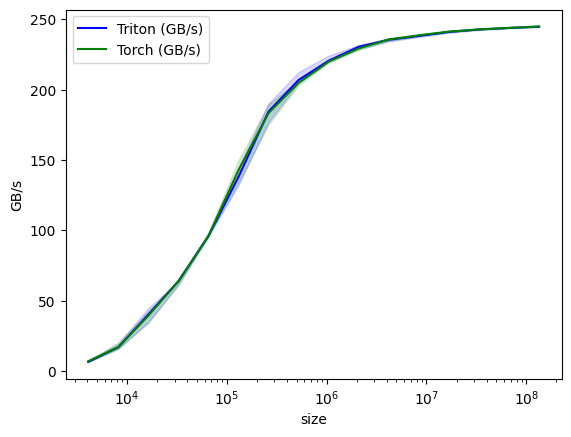

vector_add_performance:
           size  Triton (GB/s)  Torch (GB/s)
0        4096.0       6.707424      7.177570
1        8192.0      17.066666     17.114206
2       16384.0      40.288525     39.511255
3       32768.0      63.999998     63.833765
4       65536.0      96.000000     96.000000
5      131072.0     138.067414    142.883721
6      262144.0     184.435278    183.402983
7      524288.0     206.846918    204.800005
8     1048576.0     220.536180    219.919464
9     2097152.0     230.422508    229.280464
10    4194304.0     235.388203    235.635062
11    8388608.0     238.114303    238.601945
12   16777216.0     240.941181    241.195189
13   33554432.0     242.725927    242.725927
14   67108864.0     243.781660    243.822997
15  134217728.0     244.691866    244.837672


In [21]:
benchmark.run(print_data=True, show_plots=True)